# Predição de Gravidade de Acidentes em Rodovias Federais Brasileiras (2020–2025)

**Disciplina:** Tópicos em Engenharia de Software — Ciência de Dados  
**Autor:** João Ricardo Prado Siqueira — UTFPR-CM  
**Dataset:** Dados Abertos da PRF — Sistema BAT (agrupados por ocorrência)  
**Período:** 2020, 2021, 2022, 2023, 2024 (completo) + 2025 (parcial)

---

## Estrutura do Notebook

| Seção | Descrição |
|-------|-----------|
| 1 | Instalação e imports |
| 2 | Download e ingestão dos dados |
| 3 | Limpeza e padronização |
| 4 | Engenharia de features |
| 5 | Análise Exploratória (EDA) |
| 6 | Enriquecimento — Open-Meteo API |
| 7 | Análise SQL com DuckDB |
| 8 | Preparação para modelagem (split Cenário A e B) |
| 9 | Modelagem Preditiva (Regressão Logística, Random Forest, XGBoost) |
| 10 | Exportação do dataset processado e dos modelos |

---
## 1. Instalação e Imports

In [ ]:
# Instalar dependências caso necessário
# %pip install duckdb openmeteo-requests requests-cache retry-requests tqdm xgboost scikit-learn pandas seaborn matplotlib numpy

In [1]:
import os
import io
import zipfile
import requests
import warnings
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Diretórios de trabalho
DATA_RAW  = Path('data/raw')
DATA_PROC = Path('data/processed')
FIGS      = Path('figures')
for d in [DATA_RAW, DATA_PROC, FIGS]:
    d.mkdir(parents=True, exist_ok=True)

print('Ambiente configurado.')

Ambiente configurado.


---
## 2. Download e Ingestão dos Dados

Os arquivos ZIP são baixados diretamente do **Google Drive** via URL de export pública.  
Cada ZIP contém um CSV com o padrão da PRF:
- **Separador:** `;`
- **Encoding:** `ISO-8859-1`
- **Latitude/Longitude:** vírgula como separador decimal (requer conversão)

| Ano  | File ID (Google Drive)               | Tamanho ZIP |
|------|--------------------------------------|-------------|
| 2020 | `1esu6IiH5TVTxFoedv6DBGDd01Gvi8785` | ~3,0 MB     |
| 2021 | `12xH8LX9aN2gObR766YN3cMcuycwyCJDz` | ~3,1 MB     |
| 2022 | `1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-` | ~3,1 MB     |
| 2023 | `1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq` | ~3,3 MB     |
| 2024 | `14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO` | ~3,6 MB     |
| 2025 | `1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR` | ~3,7 MB     |

In [2]:
# IDs dos arquivos no Google Drive (agrupados por ocorrência — PRF)
DRIVE_FILES = {
    2020: '1esu6IiH5TVTxFoedv6DBGDd01Gvi8785',
    2021: '12xH8LX9aN2gObR766YN3cMcuycwyCJDz',
    2022: '1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-',
    2023: '1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq',
    2024: '14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO',
    2025: '1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR',
}
ANOS = sorted(DRIVE_FILES.keys())

def _gdrive_url(file_id: str) -> str:
    """Monta a URL de download direto do Google Drive."""
    return f'https://drive.google.com/uc?export=download&id={file_id}&confirm=t'

def _extrair_csv_de_zip(conteudo_zip: bytes, destino: Path, nome_final: str) -> Path:
    """Extrai o primeiro CSV do ZIP e salva com nome padronizado."""
    with zipfile.ZipFile(io.BytesIO(conteudo_zip)) as z:
        csvs = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if not csvs:
            raise ValueError(f'Nenhum CSV dentro do ZIP. Conteúdo: {z.namelist()}')
        z.extract(csvs[0], destino)
    extraido = destino / csvs[0]
    destino_final = destino / nome_final
    if extraido != destino_final:
        extraido.rename(destino_final)
    return destino_final

def download_gdrive(ano: int, file_id: str, destino: Path) -> Path | None:
    """Baixa e extrai o CSV da PRF a partir do Google Drive.
    Pula se o arquivo já existir localmente.
    """
    nome_final = f'datatran{ano}.csv'
    csv_path   = destino / nome_final

    if csv_path.exists():
        print(f'  [{ano}] ✓ Já existe ({csv_path.stat().st_size / 1e6:.1f} MB) — pulando.')
        return csv_path

    url = _gdrive_url(file_id)
    print(f'  [{ano}] Baixando de Google Drive (id={file_id})...')
    try:
        # Sessão com cookie para bypass do aviso de vírus do Drive
        session = requests.Session()
        resp = session.get(url, timeout=120, stream=True)
        resp.raise_for_status()

        # Drive pode retornar página de confirmação para arquivos grandes
        # Detecta pelo Content-Type
        content_type = resp.headers.get('Content-Type', '')
        if 'text/html' in content_type:
            # Tenta extrair token de confirmação do HTML
            token = None
            for chunk in resp.iter_content(chunk_size=4096):
                texto = chunk.decode('utf-8', errors='ignore')
                if 'confirm=' in texto:
                    import re
                    match = re.search(r'confirm=([A-Za-z0-9_-]+)', texto)
                    if match:
                        token = match.group(1)
                        break
            if token:
                url2 = f'https://drive.google.com/uc?export=download&id={file_id}&confirm={token}'
                resp = session.get(url2, timeout=120)
                resp.raise_for_status()
            else:
                print(f'  [{ano}] ✗ Drive retornou HTML sem token de confirmação.')
                return None

        conteudo = resp.content
        # Verifica assinatura ZIP
        if conteudo[:4] != b'PK\x03\x04':
            print(f'  [{ano}] ✗ Conteúdo não é um ZIP válido '
                  f'(primeiros bytes: {conteudo[:8]!r})')
            return None

        path = _extrair_csv_de_zip(conteudo, destino, nome_final)
        print(f'  [{ano}] ✓ Extraído → {path.name} '
              f'({path.stat().st_size / 1e6:.1f} MB)')
        return path

    except Exception as e:
        print(f'  [{ano}] ✗ Erro: {e}')
        return None

# --- Execução ---
print('Baixando datasets PRF do Google Drive...\n')
caminhos = {}
for ano, fid in DRIVE_FILES.items():
    resultado = download_gdrive(ano, fid, DATA_RAW)
    if resultado is not None:
        caminhos[ano] = resultado

print(f'\n--- Resumo ---')
print(f'Anos carregados:  {sorted(caminhos.keys())}')
print(f'Anos com falha:   {[a for a in ANOS if a not in caminhos]}')

Baixando datasets PRF do Google Drive...

  [2020] Baixando de Google Drive (id=1esu6IiH5TVTxFoedv6DBGDd01Gvi8785)...
  [2020] ✓ Extraído → datatran2020.csv (18.0 MB)
  [2021] Baixando de Google Drive (id=12xH8LX9aN2gObR766YN3cMcuycwyCJDz)...
  [2021] ✓ Extraído → datatran2021.csv (18.7 MB)
  [2022] Baixando de Google Drive (id=1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-)...
  [2022] ✓ Extraído → datatran2022.csv (18.7 MB)
  [2023] Baixando de Google Drive (id=1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq)...
  [2023] ✓ Extraído → datatran2023.csv (19.8 MB)
  [2024] Baixando de Google Drive (id=14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO)...
  [2024] ✓ Extraído → datatran2024.csv (21.6 MB)
  [2025] Baixando de Google Drive (id=1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR)...
  [2025] ✓ Extraído → datatran2025.csv (21.1 MB)

--- Resumo ---
Anos carregados:  [2020, 2021, 2022, 2023, 2024, 2025]
Anos com falha:   []


In [3]:
# Carregamento e concatenação de todos os anos
COLUNAS_DTYPE = {
    'id':                      str,
    'data_inversa':            str,
    'dia_semana':              str,
    'horario':                 str,
    'uf':                      str,
    'br':                      str,
    'km':                      str,   # convertido depois
    'municipio':               str,
    'causa_acidente':          str,
    'tipo_acidente':           str,
    'classificacao_acidente':  str,
    'fase_dia':                str,
    'sentido_via':             str,
    'condicao_metereologica':  str,
    'tipo_pista':              str,
    'tracado_via':             str,
    'uso_solo':                str,
    'pessoas':                 'Int64',
    'mortos':                  'Int64',
    'feridos_leves':           'Int64',
    'feridos_graves':          'Int64',
    'ilesos':                  'Int64',
    'ignorados':               'Int64',
    'feridos':                 'Int64',
    'veiculos':                'Int64',
    'latitude':                str,   # convertido depois
    'longitude':               str,
    'regional':                str,
    'delegacia':               str,
    'uop':                     str,
}

# --- Diagnóstico: quais arquivos estão disponíveis? ---
print('=== Diagnóstico de arquivos disponíveis ===')
for ano in ANOS:
    path = DATA_RAW / f'datatran{ano}.csv'
    status = f'✓ {path.stat().st_size / 1e6:.1f} MB' if path.exists() else '✗ NÃO ENCONTRADO'
    print(f'  [{ano}] {path.name}: {status}')
    if path.exists() and ano not in caminhos:
        caminhos[ano] = path   # arquivo colocado manualmente — registrar

if not caminhos:
    raise RuntimeError(
        'Nenhum arquivo CSV encontrado em data/raw/.\n'
        'Execute a célula de download acima ou coloque os CSVs '
        'manualmente como data/raw/datatran{ano}.csv'
    )

print(f'\nCarregando {len(caminhos)} ano(s): {sorted(caminhos.keys())}\n')

frames = []
for ano, path in sorted(caminhos.items()):
    try:
        df_ano = pd.read_csv(
            path,
            sep=';',
            encoding='ISO-8859-1',
            dtype=str,          # lê tudo como str primeiro para evitar erros de tipo
            low_memory=False
        )
        df_ano['ano_fonte'] = ano
        frames.append(df_ano)
        print(f'[{ano}] {len(df_ano):>7,} linhas  |  {df_ano.shape[1]} colunas  |  colunas: {list(df_ano.columns[:5])}...')
    except Exception as e:
        print(f'[{ano}] ERRO ao ler CSV: {e}')

if not frames:
    raise RuntimeError('Nenhum DataFrame foi carregado. Verifique os CSVs em data/raw/.')

# Antes de concatenar: alinhar colunas (anos diferentes podem ter colunas extras/faltantes)
todas_colunas = sorted(set(col for df in frames for col in df.columns))
frames_alinhados = [df.reindex(columns=todas_colunas) for df in frames]

df_raw = pd.concat(frames_alinhados, ignore_index=True)
print(f'\nTotal bruto concatenado: {len(df_raw):,} registros  |  {df_raw.shape[1]} colunas')
df_raw.head(3)

=== Diagnóstico de arquivos disponíveis ===
  [2020] datatran2020.csv: ✓ 18.0 MB
  [2021] datatran2021.csv: ✓ 18.7 MB
  [2022] datatran2022.csv: ✓ 18.7 MB
  [2023] datatran2023.csv: ✓ 19.8 MB
  [2024] datatran2024.csv: ✓ 21.6 MB
  [2025] datatran2025.csv: ✓ 21.1 MB

Carregando 6 ano(s): [2020, 2021, 2022, 2023, 2024, 2025]

[2020]  63,585 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...
[2021]  64,567 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...
[2022]  64,606 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...
[2023]  67,766 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...
[2024]  73,156 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...
[2025]  72,529 linhas  |  31 colunas  |  colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf']...

Total bruto concatenado: 406,20

,ano_fonte,br,causa_acidente,classificacao_acidente,condicao_metereologica,data_inversa,delegacia,dia_semana,fase_dia,feridos,feridos_graves,feridos_leves,horario,id,ignorados,ilesos,km,latitude,longitude,mortos,municipio,pessoas,regional,sentido_via,tipo_acidente,tipo_pista,tracado_via,uf,uop,uso_solo,veiculos
0,2020,316,Falta de Atenção à Condução,NaN,Céu Claro,2020-01-01,DEL01-PA,quarta-feira,Pleno dia,2,0,2,05:40:00,260068,1,0,84,"-1,3101929","-47,74456398",0,SAO FRANCISCO DO PARA,3,SPRF-PA,Decrescente,Saída de leito carroçável,Simples,Reta,PA,UOP02-DEL01-PA,Não,2
1,2020,262,Falta de Atenção à Condução,Com Vítimas Feridas,Céu Claro,2020-01-01,DEL13-MG,quarta-feira,Pleno dia,1,0,1,06:00:00,260073,0,3,804,"-19,76747537","-47,98725511",0,UBERABA,4,SPRF-MG,Decrescente,Colisão transversal,Dupla,Reta,MG,UOP01-DEL13-MG,Sim,2
2,2020,116,Condutor Dormindo,Com Vítimas Fatais,Nublado,2020-01-01,DEL07-BA,quarta-feira,Pleno dia,0,0,0,06:00:00,260087,2,0,191,"-10,32002103","-39,06425211",1,CANUDOS,2,SPRF-BA,Crescente,Saída de leito carroçável,Simples,Reta,BA,UOP02-DEL07-BA,Não,3


---
## 3. Limpeza e Padronização

### 3.1 Visão geral de completude

In [4]:
# Porcentagem de nulos por coluna
nulos = (df_raw.isna().sum() / len(df_raw) * 100).sort_values(ascending=False)
print('Completude por coluna (% nulos):')
print(nulos[nulos > 0].round(2).to_string())

Completude por coluna (% nulos):
uop                      0.0800
delegacia                0.0400
regional                 0.0100
classificacao_acidente   0.0000
tipo_acidente            0.0000


### 3.2 Tipos, datas e coordenadas

In [5]:
df = df_raw.copy()

# --- Data e hora ---
df['data_hora'] = pd.to_datetime(
    df['data_inversa'].str.strip() + ' ' + df['horario'].str.strip(),
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)
print(f'Datas inválidas: {df["data_hora"].isna().sum():,}')

# --- Coordenadas: vírgula → ponto decimal ---
for col in ['latitude', 'longitude']:
    df[col] = (
        df[col]
        .str.replace(',', '.', regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- km: vírgula → ponto ---
df['km'] = pd.to_numeric(
    df['km'].str.replace(',', '.', regex=False), errors='coerce'
)

# --- Colunas numéricas de contagem ---
contagem_cols = ['pessoas', 'mortos', 'feridos_leves', 'feridos_graves',
                 'ilesos', 'ignorados', 'feridos', 'veiculos']
for col in contagem_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# --- Padronizar strings categóricas ---
cat_cols = [
    'uf', 'municipio', 'causa_acidente', 'tipo_acidente',
    'classificacao_acidente', 'fase_dia', 'sentido_via',
    'condicao_metereologica', 'tipo_pista', 'tracado_via',
    'uso_solo', 'dia_semana'
]
for col in cat_cols:
    df[col] = df[col].str.strip().str.upper()

print('\nTipos após conversão:')
print(df.dtypes)

Datas inválidas: 0

Tipos após conversão:
ano_fonte                          int64
br                                   str
causa_acidente                       str
classificacao_acidente               str
condicao_metereologica               str
data_inversa                         str
delegacia                            str
dia_semana                           str
fase_dia                             str
feridos                            Int64
feridos_graves                     Int64
feridos_leves                      Int64
horario                              str
id                                   str
ignorados                          Int64
ilesos                             Int64
km                               float64
latitude                         float64
longitude                        float64
mortos                             Int64
municipio                            str
pessoas                            Int64
regional                             str
sentido_via    

### 3.3 Remoção de duplicatas e registros inválidos

In [6]:
n_antes = len(df)

# Duplicatas exatas (mesmo id de ocorrência)
df = df.drop_duplicates(subset='id', keep='first')
print(f'Removidas duplicatas por id: {n_antes - len(df):,}')

# Registros sem data ou coordenadas válidas
invalidos = df['data_hora'].isna()
print(f'Registros com data inválida: {invalidos.sum():,}  (mantidos para análise descritiva, excluídos da modelagem)')

# Coordenadas geograficamente inválidas para o Brasil
# Limites aproximados: lat [-33.7, 5.3], lon [-73.9, -34.8]
coord_invalidas = (
    df['latitude'].notna() & (
        (df['latitude'] < -33.7) | (df['latitude'] > 5.3) |
        (df['longitude'] < -73.9) | (df['longitude'] > -34.8)
    )
)
print(f'Coordenadas fora do Brasil: {coord_invalidas.sum():,}')
df.loc[coord_invalidas, ['latitude', 'longitude']] = np.nan

print(f'\nTotal após limpeza: {len(df):,} registros')

Removidas duplicatas por id: 0
Registros com data inválida: 0  (mantidos para análise descritiva, excluídos da modelagem)
Coordenadas fora do Brasil: 3

Total após limpeza: 406,209 registros


---
## 4. Engenharia de Features

Criamos variáveis derivadas relevantes para a análise exploratória e a modelagem.

In [7]:
# --- Variáveis temporais ---
df['ano']        = df['data_hora'].dt.year
df['mes']        = df['data_hora'].dt.month
df['hora']       = df['data_hora'].dt.hour
df['dia_mes']    = df['data_hora'].dt.day

# Período do dia (mais granular que fase_dia original)
bins_hora  = [-1, 5, 11, 17, 20, 23]
labels_hora = ['Madrugada', 'Manhã', 'Tarde', 'Noite', 'Noite']
# Simplificado:
df['periodo_dia'] = pd.cut(df['hora'], bins=[-1, 5, 11, 17, 23],
                            labels=['Madrugada','Manhã','Tarde','Noite'])

# Flag de fim de semana
df['fim_semana'] = df['data_hora'].dt.dayofweek.isin([5, 6]).astype(int)

# --- Variável-alvo: gravidade da ocorrência ---
# Baseada na classificacao_acidente do sistema BAT:
#   SEM VÍTIMAS | COM VÍTIMAS FERIDAS | COM VÍTIMAS FATAIS
# Recodificamos para variável ordinal de 3 classes:
mapa_gravidade = {
    'SEM VÍTIMAS':          0,   # Sem vítimas
    'COM VÍTIMAS FERIDAS':  1,   # Feridos
    'COM VÍTIMAS FATAIS':   2,   # Fatal
}
df['gravidade'] = (
    df['classificacao_acidente']
    .map(mapa_gravidade)
)

label_gravidade = {0: 'Sem Vítimas', 1: 'Feridos', 2: 'Fatal'}

print('Distribuição da variável-alvo (gravidade):')
print(
    df['gravidade']
    .map(label_gravidade)
    .value_counts(dropna=False)
    .rename('contagem')
    .to_frame()
    .assign(pct=lambda x: (x['contagem'] / x['contagem'].sum() * 100).round(2))
)

Distribuição da variável-alvo (gravidade):
             contagem     pct
gravidade                    
Feridos        308380 75.9200
Sem Vítimas     68679 16.9100
Fatal           29143  7.1700
NaN                 7  0.0000


In [8]:
# --- Flag: pista molhada / escorregadia ---
COND_ADVERSAS = {'CHUVA', 'GRANIZO', 'NEVE', 'NEVOEIRO/NEBLINA', 'VENTO'}
df['cond_adversa'] = df['condicao_metereologica'].isin(COND_ADVERSAS).astype(int)

# --- Flag: período noturno (horário entre 20h e 5h59) ---
df['noturno'] = df['hora'].between(20, 23) | df['hora'].between(0, 5)
df['noturno'] = df['noturno'].astype(int)

# --- Rodovia numérica ---
df['br_num'] = pd.to_numeric(df['br'], errors='coerce')

print('Features derivadas criadas com sucesso.')
df[['periodo_dia', 'fim_semana', 'gravidade', 'cond_adversa', 'noturno']].describe()

Features derivadas criadas com sucesso.


,fim_semana,gravidade,cond_adversa,noturno
count,406209.0000,406202.0000,406209.0000,406209.0000
mean,0.3286,0.9027,0.1114,0.2738
std,0.4697,0.4810,0.3146,0.4459
min,0.0000,0.0000,0.0000,0.0000
25%,0.0000,1.0000,0.0000,0.0000
50%,0.0000,1.0000,0.0000,0.0000
75%,1.0000,1.0000,0.0000,1.0000
max,1.0000,2.0000,1.0000,1.0000


---
## 5. Análise Exploratória (EDA)

### 5.1 Evolução anual dos acidentes

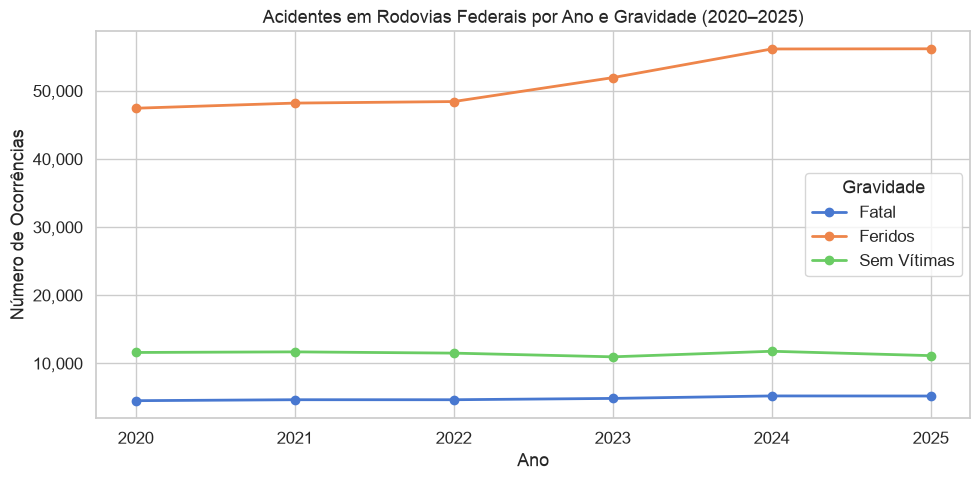

In [9]:
# Acidentes por ano e gravidade
anual = (
    df.groupby(['ano', 'gravidade'])
    .size()
    .reset_index(name='contagem')
)
anual['gravidade_label'] = anual['gravidade'].map(label_gravidade)

fig, ax = plt.subplots(figsize=(10, 5))
for g, grp in anual.groupby('gravidade_label'):
    ax.plot(grp['ano'], grp['contagem'], marker='o', label=g, linewidth=2)

ax.set_title('Acidentes em Rodovias Federais por Ano e Gravidade (2020–2025)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Número de Ocorrências')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Gravidade')
plt.tight_layout()
plt.savefig(FIGS / 'fig1_acidentes_anuais.png', dpi=150)
plt.show()

### 5.2 Distribuição por hora do dia

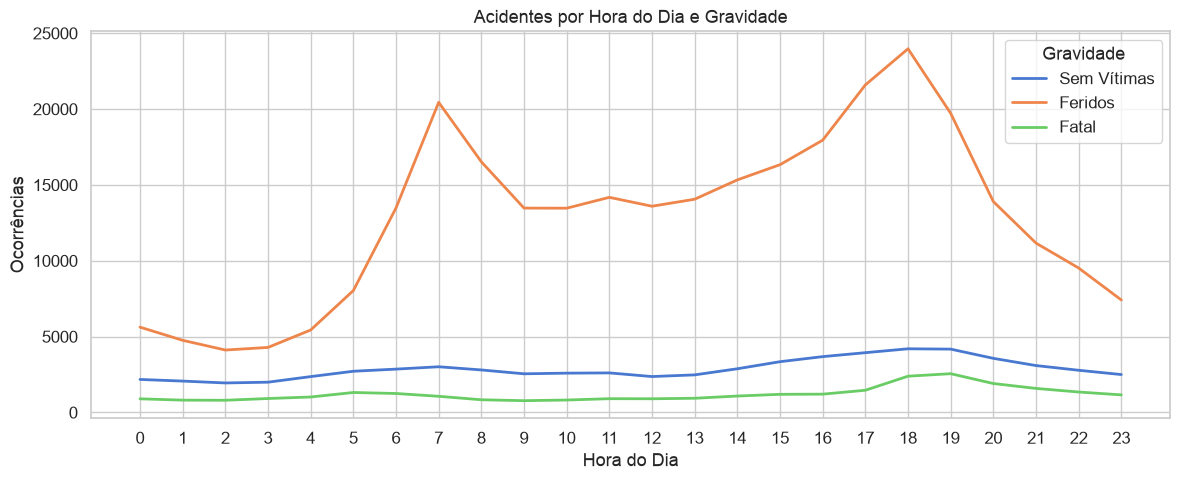

In [10]:
hora_grav = (
    df[df['gravidade'].notna()]
    .groupby(['hora', 'gravidade'])
    .size()
    .reset_index(name='n')
)
hora_grav['gravidade_label'] = hora_grav['gravidade'].map(label_gravidade)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=hora_grav, x='hora', y='n',
    hue='gravidade_label', ax=ax, linewidth=2
)
ax.set_title('Acidentes por Hora do Dia e Gravidade', fontsize=13)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Ocorrências')
ax.set_xticks(range(0, 24))
ax.legend(title='Gravidade')
plt.tight_layout()
plt.savefig(FIGS / 'fig2_hora_gravidade.png', dpi=150)
plt.show()

### 5.3 Top causas de acidentes

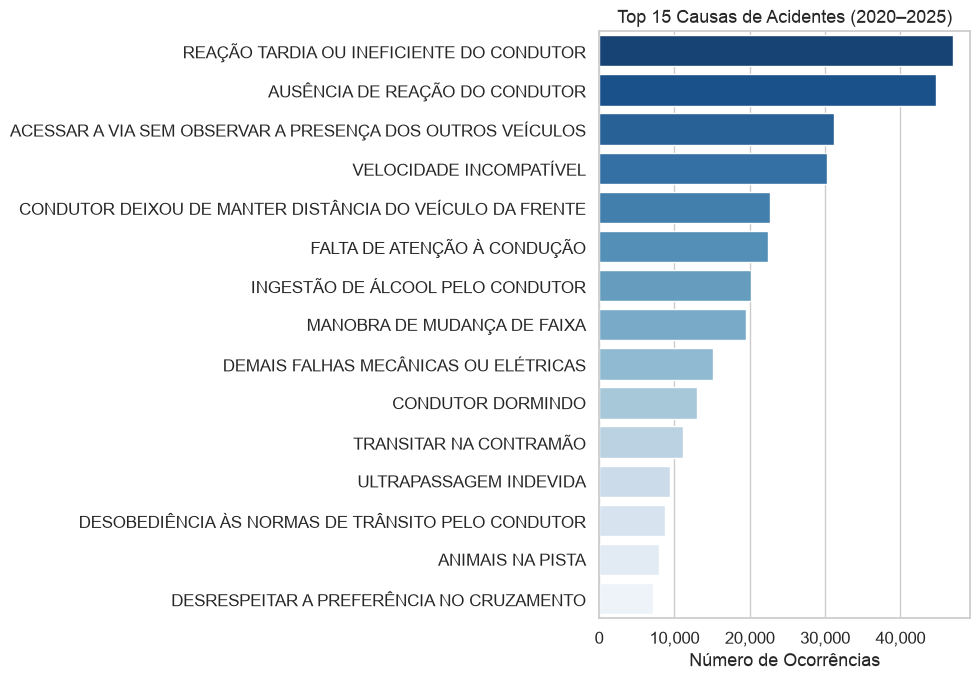

In [11]:
top_causas = (
    df['causa_acidente']
    .value_counts()
    .head(15)
    .reset_index()
)
top_causas.columns = ['causa', 'contagem']

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=top_causas, y='causa', x='contagem',
    palette='Blues_r', ax=ax
)
ax.set_title('Top 15 Causas de Acidentes (2020–2025)', fontsize=13)
ax.set_xlabel('Número de Ocorrências')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(FIGS / 'fig3_top_causas.png', dpi=150)
plt.show()

### 5.4 Gravidade × condição meteorológica adversa (H1)

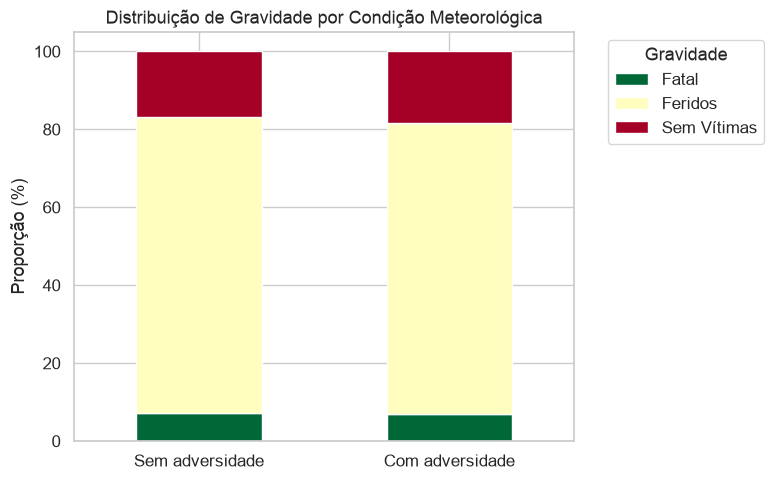


Tabela de proporções (%):
gravidade_label  Fatal  Feridos  Sem Vítimas
Sem adversidade 7.2100  76.0600      16.7300
Com adversidade 6.8700  74.8100      18.3200


In [13]:
tbl_cond = (
    df[df['gravidade'].notna()]
    .assign(gravidade_label=lambda x: x['gravidade'].map(label_gravidade))
    .groupby(['cond_adversa', 'gravidade_label'])
    .size()
    .unstack(fill_value=0)
)
# Normaliza por linha (proporção dentro de cada condição)
tbl_pct = tbl_cond.div(tbl_cond.sum(axis=1), axis=0) * 100
tbl_pct.index = ['Sem adversidade', 'Com adversidade']

tbl_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='RdYlGn_r', rot=0)
plt.title('Distribuição de Gravidade por Condição Meteorológica', fontsize=13)
plt.ylabel('Proporção (%)')
plt.xlabel('')
plt.legend(title='Gravidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGS / 'fig4_gravidade_condicao.png', dpi=150)
plt.show()

print('\nTabela de proporções (%):')
print(tbl_pct.round(2))

### 5.5 Gravidade × período (noturno vs diurno) (H1)

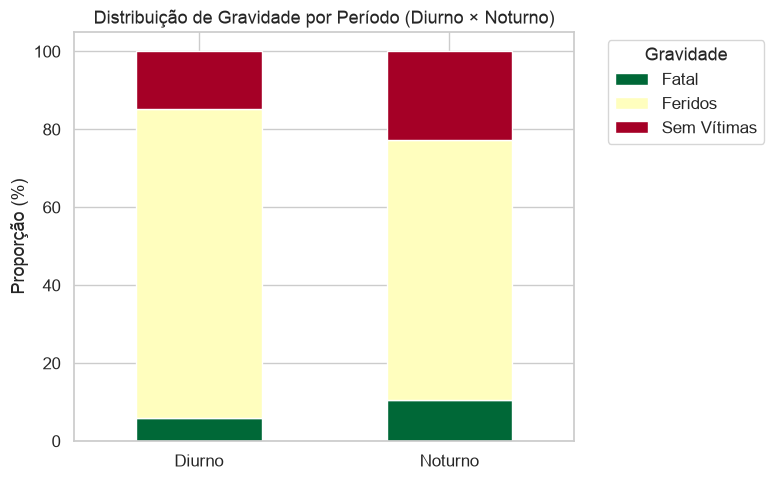


Tabela de proporções (%):
gravidade_label   Fatal  Feridos  Sem Vítimas
Diurno           5.8900  79.3700      14.7400
Noturno         10.5800  66.7700      22.6600


In [12]:
tbl_noturno = (
    df[df['gravidade'].notna()]
    .assign(gravidade_label=lambda x: x['gravidade'].map(label_gravidade))
    .groupby(['noturno', 'gravidade_label'])
    .size()
    .unstack(fill_value=0)
)
tbl_noturno_pct = tbl_noturno.div(tbl_noturno.sum(axis=1), axis=0) * 100
tbl_noturno_pct.index = ['Diurno', 'Noturno']

tbl_noturno_pct.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='RdYlGn_r', rot=0)
plt.title('Distribuição de Gravidade por Período (Diurno × Noturno)', fontsize=13)
plt.ylabel('Proporção (%)')
plt.xlabel('')
plt.legend(title='Gravidade', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig(FIGS / 'fig5_gravidade_noturno.png', dpi=150)
plt.show()

print('\nTabela de proporções (%):')
print(tbl_noturno_pct.round(2))

### 5.6 Top UFs por mortalidade

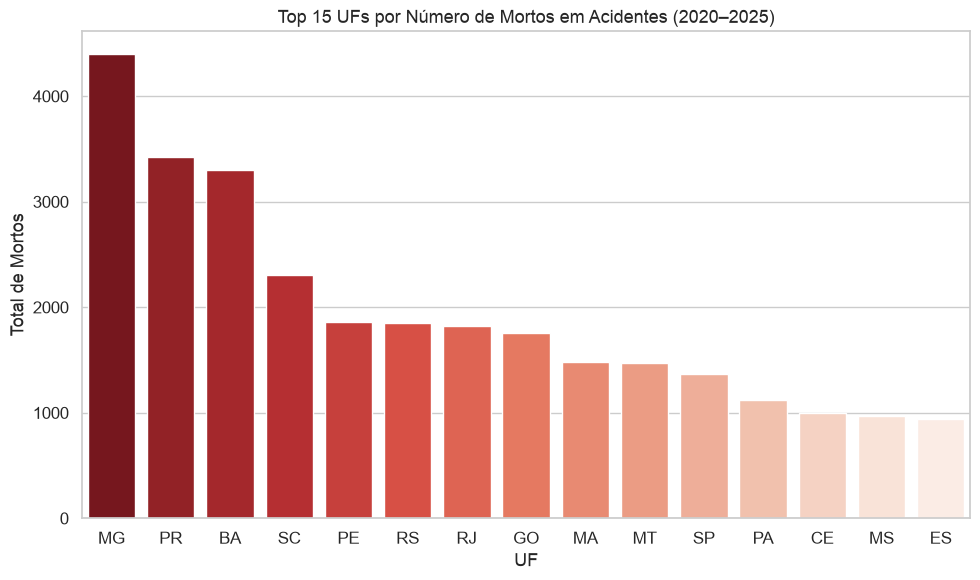

In [13]:
uf_mortes = (
    df.groupby('uf')['mortos']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=uf_mortes, x='uf', y='mortos', palette='Reds_r', ax=ax)
ax.set_title('Top 15 UFs por Número de Mortos em Acidentes (2020–2025)', fontsize=13)
ax.set_xlabel('UF')
ax.set_ylabel('Total de Mortos')
plt.tight_layout()
plt.savefig(FIGS / 'fig6_uf_mortes.png', dpi=150)
plt.show()

---
## 6. Enriquecimento com Dados Climáticos — Open-Meteo API

A [Open-Meteo Historical API](https://open-meteo.com/en/docs/historical-weather-api)  
é gratuita, sem API key, e retorna séries horárias por coordenada e data.

Variáveis recuperadas:
- `precip_mm` — precipitação total acumulada no turno (mm)
- `temp_c` — temperatura média no turno (°C)
- `visib_km` — visibilidade mínima no turno (km)

### Estratégia de agregação (redução drástica de chamadas)

| Dimensão | Granularidade | Justificativa |
|----------|--------------|---------------|
| Espaço   | Lat/lon arredondados a **1 decimal** (~11 km) | Cobre um trecho típico de rodovia federal |
| Tempo    | **Turno do dia** (madrugada/manhã/tarde/noite) | 4 turnos × 6h — clima é homogêneo dentro do turno |

Uma chamada à API busca o **dia inteiro** (24h) de uma vez e extrai os valores do turno.

```
Turnos:  Madrugada [0–5h] | Manhã [6–11h] | Tarde [12–17h] | Noite [18–23h]
Chave:   (lat_r, lon_r, data, turno)  →  1 chamada API  →  agrega médias/soma
```

Esta versão executa o enriquecimento sobre **todas** as chaves únicas
`(lat_r, lon_r, data)` do dataset. O cache em JSON
permite retomar a execução do ponto onde parou, sem refazer chamadas já
concluídas — útil caso a execução seja interrompida.

O cache é salvo em **JSON** (`data/processed/cache_clima.json`), evitando o
engine Parquet/PyArrow — que apresenta incompatibilidade conhecida com
Python 3.14 (`ArrowKeyError: No type extension with name arrow.py_extension_type`).

In [16]:
import time

# --- Mapeamento de hora → turno ---
TURNOS = {
    'Madrugada': range(0,  6),   # 00h–05h
    'Manhã':     range(6, 12),   # 06h–11h
    'Tarde':     range(12, 18),  # 12h–17h
    'Noite':     range(18, 24),  # 18h–23h
}
HORA_PARA_TURNO = {h: t for t, hrs in TURNOS.items() for h in hrs}
# Índices de hora por turno (para fatiar o array de 24h da API)
TURNO_PARA_HORAS = {t: list(hrs) for t, hrs in TURNOS.items()}

# --- Função de chamada à API (1 chamada = 1 dia inteiro, 24h) ---
def fetch_openmeteo_dia(lat: float, lon: float, date: str) -> dict:
    """Busca séries horárias de 24h para (lat, lon, date).
    Retorna dict com listas de 24 valores para precip, temp e visib.
    """
    url = 'https://archive-api.open-meteo.com/v1/archive'
    params = {
        'latitude':   lat,
        'longitude':  lon,
        'start_date': date,
        'end_date':   date,
        'hourly':     'precipitation,temperature_2m,visibility',
        'timezone':   'America/Sao_Paulo',
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    hourly = resp.json().get('hourly', {})
    return {
        'precip': hourly.get('precipitation',  [None] * 24),
        'temp':   hourly.get('temperature_2m', [None] * 24),
        'visib':  hourly.get('visibility',     [None] * 24),
    }

def agregar_turno(serie_24h: list, horas: list, func):
    """Aplica func sobre os valores do turno dentro da série de 24h.
    Ignora None antes de agregar.
    """
    valores = [serie_24h[h] for h in horas if serie_24h[h] is not None]
    return func(valores) if valores else None

# --- Preparar chaves únicas de agregação ---
df_geo = df[
    df['latitude'].notna() &
    df['longitude'].notna() &
    df['data_hora'].notna()
].copy()

df_geo['lat_r']  = df_geo['latitude'].round(1)
df_geo['lon_r']  = df_geo['longitude'].round(1)
df_geo['data_s'] = df_geo['data_hora'].dt.strftime('%Y-%m-%d')
df_geo['turno']  = df_geo['hora'].map(HORA_PARA_TURNO)

# Chave espaço-temporal: (lat_r, lon_r, data) → 1 chamada por dia
# O turno é resolvido localmente após a chamada (sem custo extra)
chaves_dia_todas = (
    df_geo[['lat_r', 'lon_r', 'data_s']]
    .drop_duplicates()
    .reset_index(drop=True)
)
print(f'Ocorrências com coordenada válida: {len(df_geo):,}')
print(f'Chaves únicas totais (lat_r, lon_r, data): {len(chaves_dia_todas):,}')

# ----------------------------------------------------------------
# MODO COMPLETO — enriquece todas as chaves únicas do dataset
# Defina SAMPLE_SIZE = <int> para voltar ao modo amostral de validação
# ----------------------------------------------------------------
SAMPLE_SIZE = None

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(chaves_dia_todas):
    chaves_dia = (
        chaves_dia_todas
        .sample(n=SAMPLE_SIZE, random_state=42)
        .reset_index(drop=True)
    )
    print(f'\n⚠ MODO AMOSTRAL ATIVO: {SAMPLE_SIZE} de {len(chaves_dia_todas):,} chaves '
          f'({SAMPLE_SIZE / len(chaves_dia_todas) * 100:.2f}%)')
else:
    chaves_dia = chaves_dia_todas
    print(f'\nModo completo: todas as {len(chaves_dia):,} chaves serão buscadas.')

print(f'Estimativa de tempo (~0.3s/chamada): {len(chaves_dia) * 0.3 / 60:.1f} min')

Ocorrências com coordenada válida: 406,206
Chaves únicas totais (lat_r, lon_r, data): 362,736

Modo completo: todas as 362,736 chaves serão buscadas.
Estimativa de tempo (~0.3s/chamada): 1813.7 min


In [17]:
# --- Cache persistente: carrega o que já foi buscado (formato JSON) ---
# JSON evita o engine Parquet/PyArrow, que apresenta incompatibilidade
# conhecida com Python 3.14 (ArrowKeyError em alguns ambientes).
import json

CACHE_PATH = DATA_PROC / 'cache_clima.json'

def _chave_str(lat_r, lon_r, data_s) -> str:
    """Converte a chave tupla em string para uso como chave JSON."""
    return f'{lat_r}|{lon_r}|{data_s}'

if CACHE_PATH.exists():
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        cache_dict = json.load(f)
    print(f'Cache carregado: {len(cache_dict):,} dias já buscados.')
else:
    cache_dict = {}
    print('Cache vazio — iniciando do zero.')

def salvar_cache():
    with open(CACHE_PATH, 'w', encoding='utf-8') as f:
        json.dump(cache_dict, f)

# --- Buscar apenas as chaves ausentes no cache ---
chaves_faltantes = [
    (row.lat_r, row.lon_r, row.data_s)
    for row in chaves_dia.itertuples()
    if _chave_str(row.lat_r, row.lon_r, row.data_s) not in cache_dict
]
print(f'Chaves a buscar: {len(chaves_faltantes):,}  |  '
      f'Já em cache: {len(chaves_dia) - len(chaves_faltantes):,}')

erros = 0
contador_novas = 0

for lat_r, lon_r, data_s in tqdm(chaves_faltantes, desc='Open-Meteo'):
    chave = _chave_str(lat_r, lon_r, data_s)
    try:
        resultado = fetch_openmeteo_dia(lat_r, lon_r, data_s)
        cache_dict[chave] = resultado
    except Exception:
        erros += 1
        cache_dict[chave] = {'precip': [None]*24, 'temp': [None]*24, 'visib': [None]*24}

    contador_novas += 1
    time.sleep(0.1)   # respeita rate limit da API gratuita

    # Salva cache a cada 100 novas entradas (amostra pequena → salva mais frequente)
    if contador_novas % 100 == 0:
        salvar_cache()

# Salva o estado final do cache
salvar_cache()

print(f'\nEnriquecimento concluído. Erros: {erros}  |  '
      f'Cache total: {len(cache_dict):,} entradas  |  '
      f'Salvo em: {CACHE_PATH}')

Cache vazio — iniciando do zero.
Chaves a buscar: 362,736  |  Já em cache: 0


Open-Meteo: 100%|██████████| 362736/362736 [104:15:31<00:00,  1.03s/it]    



Enriquecimento concluído. Erros: 269842  |  Cache total: 362,736 entradas  |  Salvo em: data/processed/cache_clima.json


In [18]:
# --- Agregar por turno e fazer merge no df principal ---
def enriquecer_linha(row):
    """Para cada ocorrência, extrai as variáveis climáticas do seu turno.
    Em modo amostral, ocorrências fora da amostra retornam NaN (esperado).
    """
    chave = _chave_str(row['lat_r'], row['lon_r'], row['data_s'])
    clima = cache_dict.get(chave)
    if clima is None:
        return pd.Series({'precip_mm': None, 'temp_c': None, 'visib_km': None})

    horas = TURNO_PARA_HORAS.get(row['turno'], list(range(24)))
    return pd.Series({
        # Precipitação: soma do turno (acumulado é mais informativo)
        'precip_mm': agregar_turno(clima['precip'], horas, sum),
        # Temperatura: média do turno
        'temp_c':    agregar_turno(clima['temp'],   horas, lambda v: sum(v)/len(v)),
        # Visibilidade: mínima do turno (pior condição)
        'visib_km':  agregar_turno(clima['visib'],  horas, min),
    })

print('Aplicando agregação por turno...')
df_geo[['precip_mm', 'temp_c', 'visib_km']] = df_geo.apply(enriquecer_linha, axis=1)

# Merge de volta no df principal pelo id da ocorrência
df = df.merge(
    df_geo[['id', 'turno', 'precip_mm', 'temp_c', 'visib_km']],
    on='id', how='left'
)

cobertura = df['precip_mm'].notna().sum()
print(f'Cobertura climática: {cobertura:,} / {len(df):,} '
      f'({cobertura/len(df)*100:.2f}%)')
if SAMPLE_SIZE is not None:
    print(f'⚠ Cobertura baixa é esperada — modo amostral com SAMPLE_SIZE={SAMPLE_SIZE}.')
    print('  Para o resultado completo, defina SAMPLE_SIZE = None e execute novamente.')
print('\nEstatísticas das variáveis climáticas (apenas registros enriquecidos):')
df[['precip_mm', 'temp_c', 'visib_km']].describe().round(2)

Aplicando agregação por turno...
Cobertura climática: 103,925 / 406,209 (25.58%)

Estatísticas das variáveis climáticas (apenas registros enriquecidos):


,precip_mm,temp_c,visib_km
count,103925.0000,103925.0000,0.0000
mean,1.1400,22.8700,NaN
std,3.2500,4.9500,NaN
min,0.0000,-1.3300,NaN
25%,0.0000,19.9000,NaN
50%,0.0000,23.3300,NaN
75%,0.6000,26.2300,NaN
max,127.6000,39.7700,NaN


---
## 7. Análise SQL com DuckDB

Usamos o DuckDB diretamente sobre o DataFrame Pandas  
(sem necessidade de exportar para arquivo).

In [19]:
con = duckdb.connect()
con.register('acidentes', df)

In [20]:
# Q1 — Taxa de mortalidade por tipo de pista
q1 = """
SELECT
    tipo_pista,
    COUNT(*)                                    AS total_ocorrencias,
    SUM(mortos)                                 AS total_mortos,
    ROUND(SUM(mortos) * 100.0 / COUNT(*), 2)   AS taxa_mortalidade_pct
FROM acidentes
WHERE tipo_pista IS NOT NULL
GROUP BY tipo_pista
ORDER BY taxa_mortalidade_pct DESC
"""
print('Q1 — Taxa de mortalidade por tipo de pista:')
con.execute(q1).df()

Q1 — Taxa de mortalidade por tipo de pista:


,tipo_pista,total_ocorrencias,total_mortos,taxa_mortalidade_pct
0,SIMPLES,199594,23610.0000,11.8300
1,DUPLA,169713,8768.0000,5.1700
2,MÚLTIPLA,36902,1582.0000,4.2900


In [21]:
# Q2 — Acidentes fatais por dia da semana e período
q2 = """
SELECT
    dia_semana,
    noturno,
    COUNT(*)                                        AS total,
    SUM(CASE WHEN gravidade = 2 THEN 1 ELSE 0 END) AS fatais,
    ROUND(
        SUM(CASE WHEN gravidade = 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
    2) AS pct_fatal
FROM acidentes
WHERE dia_semana IS NOT NULL
GROUP BY dia_semana, noturno
ORDER BY pct_fatal DESC
LIMIT 20
"""
print('Q2 — Acidentes fatais por dia da semana e período noturno:')
con.execute(q2).df()

Q2 — Acidentes fatais por dia da semana e período noturno:


,dia_semana,noturno,total,fatais,pct_fatal
0,DOMINGO,1,23734,2672.0000,11.2600
1,SÁBADO,1,22746,2412.0000,10.6000
2,SEXTA-FEIRA,1,16585,1735.0000,10.4600
3,QUARTA-FEIRA,1,11658,1218.0000,10.4500
4,SEGUNDA-FEIRA,1,13206,1371.0000,10.3800
5,TERÇA-FEIRA,1,10661,1080.0000,10.1300
6,QUINTA-FEIRA,1,12634,1275.0000,10.0900
7,DOMINGO,0,42968,3173.0000,7.3800
8,SÁBADO,0,44039,2932.0000,6.6600
9,QUINTA-FEIRA,0,39959,2221.0000,5.5600


In [22]:
# Q3 — Top 10 municípios com maior número de mortos
q3 = """
SELECT
    uf,
    municipio,
    COUNT(*)     AS ocorrencias,
    SUM(mortos)  AS mortos_total
FROM acidentes
WHERE municipio IS NOT NULL
GROUP BY uf, municipio
ORDER BY mortos_total DESC
LIMIT 10
"""
print('Q3 — Top 10 municípios por número de mortos:')
con.execute(q3).df()

Q3 — Top 10 municípios por número de mortos:


,uf,municipio,ocorrencias,mortos_total
0,DF,BRASILIA,5988,248.0000
1,PR,CURITIBA,4724,170.0000
2,PR,SAO JOSE DOS PINHAIS,2702,164.0000
3,SP,GUARULHOS,4553,159.0000
4,RO,PORTO VELHO,2326,154.0000
5,RJ,CAMPOS DOS GOYTACAZES,1962,143.0000
6,PR,CASCAVEL,1902,143.0000
7,MS,CAMPO GRANDE,1783,142.0000
8,SP,SAO PAULO,1961,141.0000
9,RJ,DUQUE DE CAXIAS,4037,136.0000


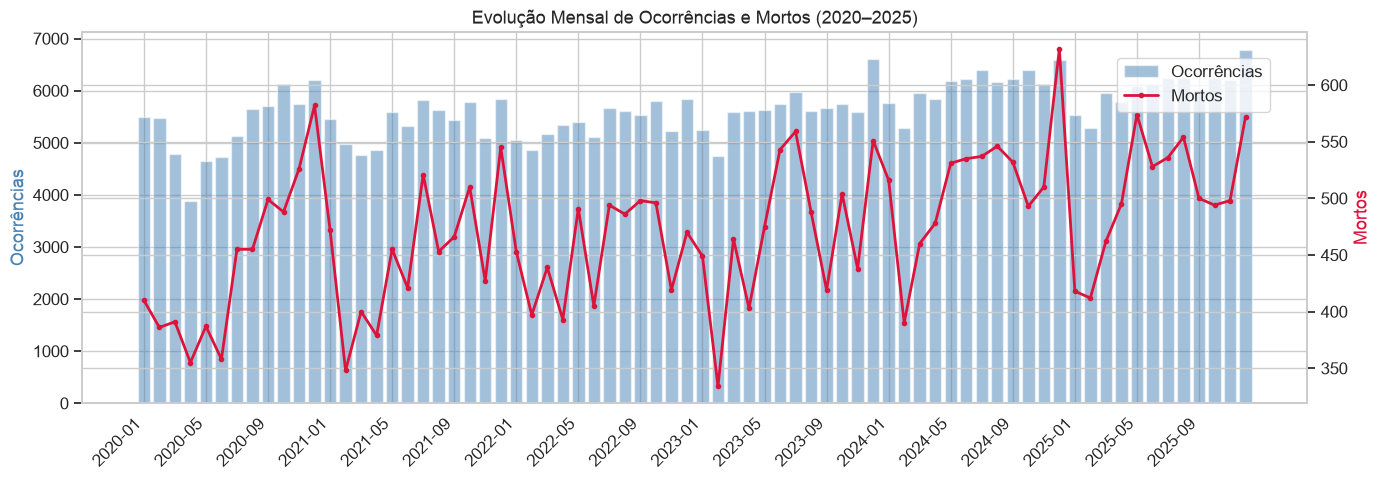

In [23]:
# Q4 — Evolução mensal de acidentes fatais (tendência temporal)
q4 = """
SELECT
    STRFTIME(data_hora, '%Y-%m')             AS ano_mes,
    COUNT(*)                                 AS ocorrencias,
    SUM(mortos)                              AS mortos
FROM acidentes
WHERE data_hora IS NOT NULL
GROUP BY ano_mes
ORDER BY ano_mes
"""
df_mensal = con.execute(q4).df()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(df_mensal['ano_mes'], df_mensal['ocorrencias'],
        color='steelblue', alpha=0.5, label='Ocorrências')
ax2.plot(df_mensal['ano_mes'], df_mensal['mortos'],
         color='crimson', linewidth=2, marker='.', label='Mortos')

# Reduz labels do eixo X
step = max(1, len(df_mensal) // 18)
ax1.set_xticks(range(0, len(df_mensal), step))
ax1.set_xticklabels(df_mensal['ano_mes'].iloc[::step], rotation=45, ha='right')

ax1.set_title('Evolução Mensal de Ocorrências e Mortos (2020–2025)', fontsize=13)
ax1.set_ylabel('Ocorrências', color='steelblue')
ax2.set_ylabel('Mortos', color='crimson')
fig.legend(loc='upper right', bbox_to_anchor=(0.92, 0.88))
plt.tight_layout()
plt.savefig(FIGS / 'fig7_mensal.png', dpi=150)
plt.show()

In [24]:
# Q5 — Impacto da precipitação na gravidade (requer enriquecimento)
# ⚠ Em modo amostral (SAMPLE_SIZE ativo), esta query usa apenas a fração
# de registros que foram efetivamente enriquecidos — resultado parcial.
con.register('acidentes', df)  # re-registra com as colunas de clima já mescladas

q5 = """
SELECT
    CASE
        WHEN precip_mm = 0           THEN 'Sem chuva'
        WHEN precip_mm BETWEEN 0 AND 2  THEN 'Chuva leve (0–2 mm)'
        WHEN precip_mm BETWEEN 2 AND 10 THEN 'Chuva moderada (2–10 mm)'
        ELSE 'Chuva intensa (>10 mm)'
    END AS faixa_precip,
    COUNT(*)                                         AS total,
    ROUND(AVG(mortos), 4)                            AS media_mortos,
    SUM(CASE WHEN gravidade = 2 THEN 1 ELSE 0 END)  AS fatais,
    ROUND(
        SUM(CASE WHEN gravidade = 2 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
    2) AS pct_fatal
FROM acidentes
WHERE precip_mm IS NOT NULL AND gravidade IS NOT NULL
GROUP BY faixa_precip
ORDER BY pct_fatal DESC
"""
resultado_q5 = con.execute(q5).df()
n_enriquecidos = df['precip_mm'].notna().sum()
print(f'Q5 — Gravidade por faixa de precipitação (base: {n_enriquecidos:,} registros enriquecidos):')
if SAMPLE_SIZE is not None:
    print('⚠ Resultado PARCIAL — amostra reduzida, não usar para conclusões finais.')
resultado_q5

Q5 — Gravidade por faixa de precipitação (base: 103,925 registros enriquecidos):


,faixa_precip,total,media_mortos,fatais,pct_fatal
0,Sem chuva,58503,0.0891,4496.0000,7.6900
1,Chuva leve (0–2 mm),31065,0.0807,2140.0000,6.8900
2,Chuva moderada (2–10 mm),11618,0.0813,779.0000,6.7100
3,Chuva intensa (>10 mm),2737,0.0764,168.0000,6.1400


---
## 8. Preparação para Modelagem

Seleção de features, codificação categórica e split treino/teste — gerando
dois conjuntos de features (Cenário A sem clima, Cenário B com clima) sobre
o **mesmo split** de linhas, para uma comparação controlada na Seção 9.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features comuns (Cenário A — sem enriquecimento climático)
FEATURES_CAT = [
    'uf', 'causa_acidente', 'tipo_acidente',
    'fase_dia', 'condicao_metereologica',
    'tipo_pista', 'tracado_via', 'uso_solo', 'dia_semana'
]
FEATURES_NUM_A = [
    'hora', 'mes', 'veiculos', 'pessoas',
    'noturno', 'fim_semana', 'cond_adversa', 'km'
]
# Features climáticas exclusivas do Cenário B
FEATURES_CLIMA = ['precip_mm', 'temp_c', 'visib_km']
TARGET = 'gravidade'

# Remove visib_km automaticamente se estiver 100% nula (ver Seção 6)
cobertura_visib = df['visib_km'].notna().mean()
if cobertura_visib == 0:
    print(f'⚠ visib_km 100% nula — removida das features climáticas do Cenário B.')
    FEATURES_CLIMA = [c for c in FEATURES_CLIMA if c != 'visib_km']
else:
    print(f'Cobertura de visib_km: {cobertura_visib*100:.1f}% — mantida nas features.')

FEATURES_NUM_B = FEATURES_NUM_A + FEATURES_CLIMA

df_model = df[
    FEATURES_CAT + FEATURES_NUM_B + [TARGET]
].dropna(subset=[TARGET.groupby('gravidade_label')]).copy()

# Label Encoding nas categóricas (mesmo encoder para os dois cenários)
encoders = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].fillna('DESCONHECIDO').astype(str))
    encoders[col] = le

# Preencher nulos numéricos com a mediana (cada coluna, incluindo as climáticas)
for col in FEATURES_NUM_B:
    mediana = df_model[col].median()
    df_model[col] = df_model[col].fillna(mediana)

y = df_model[TARGET].astype(int)

# --- UM ÚNICO split de índices, reaproveitado nos dois cenários ---
# Garante que A e B sejam comparados sobre exatamente as mesmas linhas de treino/teste.
idx_train, idx_test = train_test_split(
    df_model.index, test_size=0.2, random_state=42, stratify=y
)

# Cenário A — sem clima
X_A = df_model[FEATURES_CAT + FEATURES_NUM_A].astype(float)
X_train_A, X_test_A = X_A.loc[idx_train], X_A.loc[idx_test]

# Cenário B — com clima
X_B = df_model[FEATURES_CAT + FEATURES_NUM_B].astype(float)
X_train_B, X_test_B = X_B.loc[idx_train], X_B.loc[idx_test]

# Target (igual para os dois cenários)
y_train, y_test = y.loc[idx_train], y.loc[idx_test]

# Mantém os nomes X_train/X_test/X (Cenário A) para compatibilidade com a
# Seção 9 (exportação), que já espera essas variáveis
X_train, X_test = X_train_A, X_test_A
X = X_A

print(f'Treino: {len(idx_train):,}  |  Teste: {len(idx_test):,}')
print(f'Features Cenário A (sem clima): {X_train_A.shape[1]}  |  '
      f'Features Cenário B (com clima): {X_train_B.shape[1]}')
print(f'\nDistribuição no treino:\n{y_train.value_counts().sort_index()}')

⚠ visib_km 100% nula — removida das features climáticas do Cenário B.
Treino: 324,961  |  Teste: 81,241
Features Cenário A (sem clima): 17  |  Features Cenário B (com clima): 19

Distribuição no treino:
gravidade
0     54943
1    246704
2     23314
Name: count, dtype: int64


In [26]:
# Verificação de data leakage: nenhuma feature derivada da variável-alvo
leakage_check = [c for c in ['mortos', 'feridos_leves', 'feridos_graves',
                              'ilesos', 'feridos', 'classificacao_acidente']
                 if c in X.columns]
assert len(leakage_check) == 0, f'Possível leakage detectado: {leakage_check}'
print('Verificação de data leakage: OK')

Verificação de data leakage: OK


---
## 8. Modelagem Preditiva

Treinamos três classificadores — Regressão Logística (baseline), Random Forest
e XGBoost — em dois cenários experimentais:

- **Cenário A:** apenas as features originais da PRF (sem clima).
- **Cenário B:** features do Cenário A + variáveis climáticas da Open-Meteo
  (`precip_mm`, `temp_c` e `visib_km`, caso disponível — ver Seção 6).

Os dois cenários usam exatamente o mesmo split de treino/teste (mesmas linhas),
garantindo que a comparação isole o efeito do enriquecimento climático.

Métricas reportadas no conjunto de teste: **F1-macro**, **AUC-ROC (OvR)** e
**acurácia balanceada**, conforme o protocolo de avaliação definido no artigo.

In [27]:
# %pip install xgboost --quiet

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42

def treinar_e_avaliar(modelo, nome: str, X_tr, X_te, y_tr, y_te, escalar=False):
    """Treina um modelo e retorna um dicionário com as métricas de avaliação.
    escalar=True aplica StandardScaler (necessário para Regressão Logística).
    """
    if escalar:
        scaler = StandardScaler()
        X_tr_proc = scaler.fit_transform(X_tr)
        X_te_proc = scaler.transform(X_te)
    else:
        X_tr_proc, X_te_proc = X_tr, X_te

    modelo.fit(X_tr_proc, y_tr)
    y_pred = modelo.predict(X_te_proc)
    y_proba = modelo.predict_proba(X_te_proc)

    metricas = {
        'modelo':          nome,
        'f1_macro':        f1_score(y_te, y_pred, average='macro'),
        'auc_roc_ovr':     roc_auc_score(y_te, y_proba, multi_class='ovr', average='macro'),
        'acuracia_bal':    balanced_accuracy_score(y_te, y_pred),
        'y_pred':          y_pred,
        'y_proba':         y_proba,
        'modelo_obj':      modelo,
    }
    return metricas

print('Funções de treino e avaliação definidas.')

Funções de treino e avaliação definidas.


In [28]:
# ============================================================
# CENÁRIO A — Sem enriquecimento climático
# ============================================================
print('=== Cenário A: treinando modelos (sem clima) ===\n')

resultados_A = []

# 1. Regressão Logística (requer features padronizadas)
print('[A] Regressão Logística...')
log_reg_A = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs',
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
res = treinar_e_avaliar(log_reg_A, 'Regressão Logística', X_train_A, X_test_A, y_train, y_test, escalar=True)
resultados_A.append(res)

# 2. Random Forest
print('[A] Random Forest...')
rf_A = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
res = treinar_e_avaliar(rf_A, 'Random Forest', X_train_A, X_test_A, y_train, y_test)
resultados_A.append(res)

# 3. XGBoost
print('[A] XGBoost...')
xgb_A = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
)
res = treinar_e_avaliar(xgb_A, 'XGBoost', X_train_A, X_test_A, y_train, y_test)
resultados_A.append(res)

print('\n=== Resultados — Cenário A ===')
tabela_A = pd.DataFrame([
    {'Modelo': r['modelo'], 'F1-macro': r['f1_macro'],
     'AUC-ROC': r['auc_roc_ovr'], 'Acurácia Bal.': r['acuracia_bal']}
    for r in resultados_A
]).round(4)
tabela_A

=== Cenário A: treinando modelos (sem clima) ===

[A] Regressão Logística...
[A] Random Forest...
[A] XGBoost...

=== Resultados — Cenário A ===


,Modelo,F1-macro,AUC-ROC,Acurácia Bal.
0,Regressão Logística,0.3994,0.6705,0.5229
1,Random Forest,0.5315,0.7845,0.6148
2,XGBoost,0.4932,0.8032,0.4560


In [29]:
# ============================================================
# CENÁRIO B — Com enriquecimento climático
# ============================================================
print('=== Cenário B: treinando modelos (com clima) ===\n')

resultados_B = []

print('[B] Regressão Logística...')
log_reg_B = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs',
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
res = treinar_e_avaliar(log_reg_B, 'Regressão Logística', X_train_B, X_test_B, y_train, y_test, escalar=True)
resultados_B.append(res)

print('[B] Random Forest...')
rf_B = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=5,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
res = treinar_e_avaliar(rf_B, 'Random Forest', X_train_B, X_test_B, y_train, y_test)
resultados_B.append(res)

print('[B] XGBoost...')
xgb_B = XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
)
res = treinar_e_avaliar(xgb_B, 'XGBoost', X_train_B, X_test_B, y_train, y_test)
resultados_B.append(res)

print('\n=== Resultados — Cenário B ===')
tabela_B = pd.DataFrame([
    {'Modelo': r['modelo'], 'F1-macro': r['f1_macro'],
     'AUC-ROC': r['auc_roc_ovr'], 'Acurácia Bal.': r['acuracia_bal']}
    for r in resultados_B
]).round(4)
tabela_B

=== Cenário B: treinando modelos (com clima) ===

[B] Regressão Logística...
[B] Random Forest...
[B] XGBoost...

=== Resultados — Cenário B ===


,Modelo,F1-macro,AUC-ROC,Acurácia Bal.
0,Regressão Logística,0.3999,0.6708,0.5230
1,Random Forest,0.5292,0.7842,0.6144
2,XGBoost,0.4931,0.8035,0.4558


In [30]:
# --- Comparação A vs B: efeito do enriquecimento climático ---
comparacao = tabela_A.merge(
    tabela_B, on='Modelo', suffixes=(' (A)', ' (B)')
)
comparacao['Δ F1-macro'] = (
    comparacao['F1-macro (B)'] - comparacao['F1-macro (A)']
).round(4)

print('Tabela completa (responde PR2):')
comparacao[['Modelo', 'F1-macro (A)', 'F1-macro (B)', 'Δ F1-macro',
            'AUC-ROC (B)', 'Acurácia Bal. (B)']]

Tabela completa (responde PR2):


,Modelo,F1-macro (A),F1-macro (B),Δ F1-macro,AUC-ROC (B),Acurácia Bal. (B)
0,Regressão Logística,0.3994,0.3999,0.0005,0.6708,0.5230
1,Random Forest,0.5315,0.5292,-0.0023,0.7842,0.6144
2,XGBoost,0.4932,0.4931,-0.0001,0.8035,0.4558


Top 15 variáveis mais importantes (Random Forest, Cenário B):
tipo_acidente            0.2473
causa_acidente           0.1152
pessoas                  0.0935
km                       0.0866
veiculos                 0.0669
uf                       0.0634
hora                     0.0549
mes                      0.0482
dia_semana               0.0340
tracado_via              0.0339
tipo_pista               0.0275
temp_c                   0.0256
uso_solo                 0.0224
condicao_metereologica   0.0200
fase_dia                 0.0200
dtype: float64


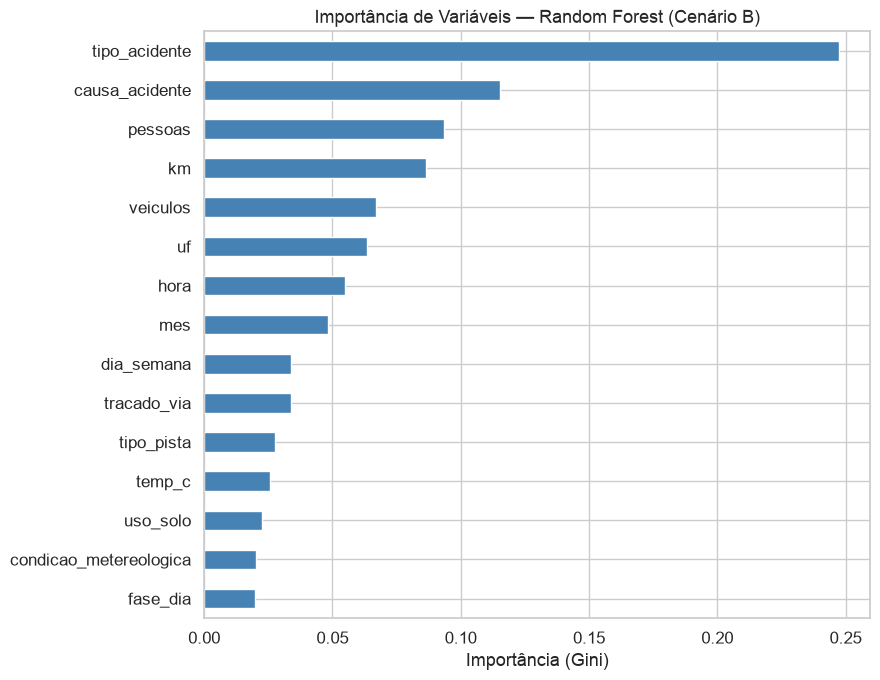

In [31]:
# --- Importância de variáveis (responde PR1) — Random Forest do Cenário B ---
importancias = pd.Series(
    rf_B.feature_importances_, index=X_train_B.columns
).sort_values(ascending=False)

print('Top 15 variáveis mais importantes (Random Forest, Cenário B):')
print(importancias.head(15).round(4))

fig, ax = plt.subplots(figsize=(9, 7))
importancias.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância de Variáveis — Random Forest (Cenário B)', fontsize=13)
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig(FIGS / 'fig8_importancia_variaveis.png', dpi=150)
plt.show()

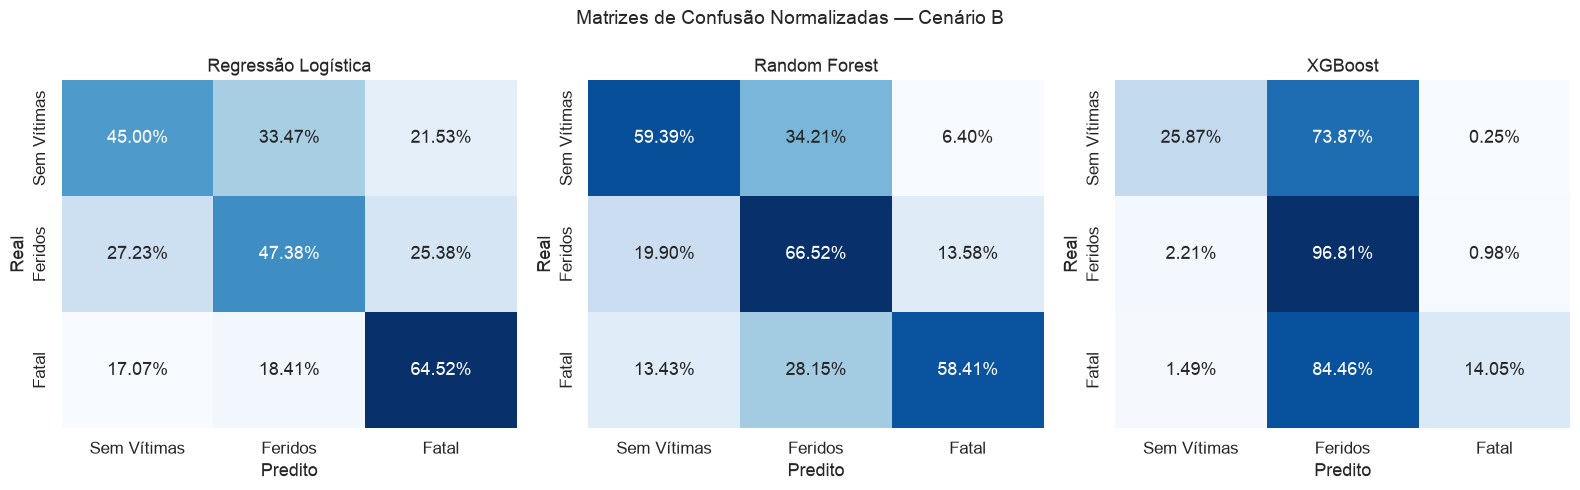


Relatório de classificação detalhado — melhor modelo por F1-macro:
Melhor modelo (Cenário B): Random Forest

              precision    recall  f1-score   support

 Sem Vítimas       0.38      0.59      0.47     13736
     Feridos       0.87      0.67      0.75     61676
       Fatal       0.27      0.58      0.37      5829

    accuracy                           0.65     81241
   macro avg       0.51      0.61      0.53     81241
weighted avg       0.74      0.65      0.68     81241



In [32]:
# --- Matrizes de confusão dos três modelos (Cenário B) ---
labels_plot = ['Sem Vítimas', 'Feridos', 'Fatal']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res in zip(axes, resultados_B):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt='.2%', cmap='Blues',
        xticklabels=labels_plot, yticklabels=labels_plot, ax=ax, cbar=False
    )
    ax.set_title(res['modelo'])
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de Confusão Normalizadas — Cenário B', fontsize=14)
plt.tight_layout()
plt.savefig(FIGS / 'fig9_matrizes_confusao.png', dpi=150)
plt.show()

print('\nRelatório de classificação detalhado — melhor modelo por F1-macro:')
melhor = max(resultados_B, key=lambda r: r['f1_macro'])
print(f"Melhor modelo (Cenário B): {melhor['modelo']}\n")
print(classification_report(y_test, melhor['y_pred'], target_names=labels_plot))

In [33]:
# --- Exportar tabelas de resultados para uso no artigo (.tex) ---
comparacao.to_csv(DATA_PROC / 'resultados_modelagem.csv', index=False)
importancias.head(15).to_csv(DATA_PROC / 'importancia_variaveis.csv')

print('Tabelas de resultados exportadas para data/processed/:')
print('  - resultados_modelagem.csv  (Tabelas 5 e 6 do artigo)')
print('  - importancia_variaveis.csv (Figura de importância)')
print(f'\nMelhor modelo geral (maior F1-macro, Cenário B): {melhor["modelo"]} '
      f'(F1={melhor["f1_macro"]:.4f})')

Tabelas de resultados exportadas para data/processed/:
  - resultados_modelagem.csv  (Tabelas 5 e 6 do artigo)
  - importancia_variaveis.csv (Figura de importância)

Melhor modelo geral (maior F1-macro, Cenário B): Random Forest (F1=0.5292)


---
## 10. Exportação do Dataset Processado e dos Modelos

In [34]:
def salvar_df(dataframe, path_base: Path):
    """Salva em Parquet; em caso de falha do engine (ex.: bug PyArrow/Python 3.14),
    faz fallback automático para CSV com o mesmo nome base.
    """
    try:
        path_parquet = path_base.with_suffix('.parquet')
        dataframe.to_parquet(path_parquet, index=False)
        return path_parquet
    except Exception as e:
        print(f'  ⚠ Falha ao salvar Parquet ({type(e).__name__}) — usando CSV como fallback.')
        path_csv = path_base.with_suffix('.csv')
        dataframe.to_csv(path_csv, index=False)
        return path_csv

# Dataset completo processado
salvar_df(df, DATA_PROC / 'acidentes_prf_2020_2025_processado')

# Conjuntos de treino e teste — Cenário A (sem clima)
salvar_df(X_train_A,           DATA_PROC / 'X_train_A')
salvar_df(X_test_A,            DATA_PROC / 'X_test_A')

# Conjuntos de treino e teste — Cenário B (com clima)
salvar_df(X_train_B,           DATA_PROC / 'X_train_B')
salvar_df(X_test_B,            DATA_PROC / 'X_test_B')

# Target (compartilhado pelos dois cenários)
salvar_df(y_train.to_frame(),  DATA_PROC / 'y_train')
salvar_df(y_test.to_frame(),   DATA_PROC / 'y_test')

# Modelos treinados (Cenário B — usado nas Figuras 8 e 9)
import pickle
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)
for nome, modelo in [('logreg_B', log_reg_B), ('rf_B', rf_B), ('xgb_B', xgb_B)]:
    with open(MODELS_DIR / f'{nome}.pkl', 'wb') as f:
        pickle.dump(modelo, f)

print('\nArquivos exportados:')
for f in sorted(DATA_PROC.iterdir()):
    print(f'  data/processed/{f.name}  ({f.stat().st_size / 1e6:.1f} MB)')
for f in sorted(MODELS_DIR.iterdir()):
    print(f'  models/{f.name}  ({f.stat().st_size / 1e6:.1f} MB)')

print('\n=== Pipeline de processamento e modelagem concluído ===')
if SAMPLE_SIZE is not None:
    print(f'⚠ Lembrete: enriquecimento climático em modo amostral (SAMPLE_SIZE={SAMPLE_SIZE}).')
else:
    cobertura_final = df['precip_mm'].notna().mean() * 100
    print(f'Cobertura climática final: {cobertura_final:.1f}% das ocorrências.')

  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.
  ⚠ Falha ao salvar Parquet (ImportError) — usando CSV como fallback.

Arquivos exportados:
  data/processed/X_test_A.csv  (6.1 MB)
  data/processed/X_test_B.csv  (7.9 MB)
  data/processed/X_train_A.csv  (24.2 MB)
  data/processed/X_train_B.csv  (31.6 MB)
  data/processed/acidentes_prf_2020_2025_processado.csv  (136.7 MB)
  data/processed/cache_clima.json  (176.5 MB)
  data/processed/importancia_variaveis.csv  (0.0 MB)
  data/processed/resultados_modelagem.csv  (0.0 MB)
  data/processed/y_test.csv  (0.2 MB)
  data/processed/y_train.csv  (0.6 MB)
  models/logreg_B.pkl  (0.0 